<a href="https://colab.research.google.com/github/Fransalchipapas/analisis-proyectos-mineros-mendoza-/blob/branch_1/Proyecto_Energ%C3%ADas_Renovables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Energías Alternativas en Argentina

**Etapa 1: Exploración, transformación y visualización**

**Objetivo**

Analizar características sobre datos de generación y potencia instalada de fuentes de energía Eólica, PAH (pequeños aprovechamientos hidroeléctricos), Solar, Biomasa, Biogas, Nuclear.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
pd.read_csv("/content/energias-alternativas.csv", encoding='latin-1')

,sector_id,sector_nombre,variable_id,actividad_producto_nombre,indicador,unidad_de_medida,fuente,frecuencia_nombre,cobertura_nombre,alcance_tipo,alcance_id,alcance_nombre,indice_tiempo,valor
0,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-01-01,0.000
1,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-02-01,0.000
2,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-03-01,0.000
3,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-04-01,0.000
4,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-05-01,764.924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5306,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-08-01,61.200
5307,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-09-01,61.200
5308,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-10-01,61.200
5309,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-11-01,61.200


In [3]:
df = pd.read_csv("/content/energias-alternativas.csv", encoding='latin-1')

In [4]:
df

,sector_id,sector_nombre,variable_id,actividad_producto_nombre,indicador,unidad_de_medida,fuente,frecuencia_nombre,cobertura_nombre,alcance_tipo,alcance_id,alcance_nombre,indice_tiempo,valor
0,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-01-01,0.000
1,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-02-01,0.000
2,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-03-01,0.000
3,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-04-01,0.000
4,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-05-01,764.924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5306,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-08-01,61.200
5307,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-09-01,61.200
5308,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-10-01,61.200
5309,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-11-01,61.200


**Exploración**

Las columnas son:

- sector_id:	Código numérico del sector
- sector_nombre:	Nombre del sector
- variable_id: Código único de cada combinación energía + indicador
- actividad_producto_nombre: Tipo de energía
- indicador: Qué se está midiendo
- unidad_de_medida: Unidad de valor
- fuente: Organismo que publica el dato
- frecuencia_nombre: Periodicidad de los datos
- cobertura_nombre: Cobertura geográfica general
- alcance_tipo: Nivel geográfico del dato
- alcance_id: Código de la provincia
- alcance_nombre: Nombre de la procincia
- indice_tiempo: Fecha del registro
- valor: La medición

In [30]:
df = df.rename(columns={
    'sector_id': 'id_Sector',
    'sector_nombre': 'Nombre_Sector',
    'variable_id': 'id_variable',
    'actividad_producto_nombre': 'tipo_energia',
    'frecuencia_nombre': 'frecuencia_datos',
    'cobertura_nombre': 'cobertura_geografica',
    'alcance_id': 'Codigo_Provincia',
    'alcance_nombre': 'provincia',
    'indice_tiempo': 'Fecha_Registro',
    'valor': 'Medicion'
})

In [31]:
df


,id_Sector,Nombre_Sector,id_variable,tipo_energia,indicador,unidad_de_medida,fuente,frecuencia_datos,cobertura_geografica,alcance_tipo,Codigo_Provincia,provincia,Fecha_Registro,Medicion
0,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-01-01,0.000
1,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-02-01,0.000
2,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-03-01,0.000
3,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-04-01,0.000
4,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-05-01,764.924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5306,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-08-01,61.200
5307,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-09-01,61.200
5308,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-10-01,61.200
5309,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-11-01,61.200


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311 entries, 0 to 5310
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_Sector             5311 non-null   int64  
 1   Nombre_Sector         5311 non-null   object 
 2   id_variable           5311 non-null   int64  
 3   tipo_energia          5311 non-null   object 
 4   indicador             5311 non-null   object 
 5   unidad_de_medida      5311 non-null   object 
 6   fuente                5311 non-null   object 
 7   frecuencia_datos      5311 non-null   object 
 8   cobertura_geografica  5311 non-null   object 
 9   alcance_tipo          5311 non-null   object 
 10  Codigo_Provincia      5311 non-null   int64  
 11  provincia             5311 non-null   object 
 12  Fecha_Registro        5311 non-null   object 
 13  Medicion              5311 non-null   float64
dtypes: float64(1), int64(3), object(10)
memory usage: 581.0+ KB


In [35]:
df['id_variable'].unique()

array([440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450])

In [36]:
df['id_variable'].nunique()

11

In [39]:
df[['id_Sector', 'Nombre_Sector', 'id_variable', 'tipo_energia', 'indicador', 'cobertura_geografica', 'alcance_tipo', 'Codigo_Provincia', 'provincia' ]].value_counts()

id_Sector  Nombre_Sector          id_variable  tipo_energia     indicador           cobertura_geografica  alcance_tipo  Codigo_Provincia  provincia   
25         Energías alternativas  445          Energía nuclear  Generación          Nacional              PROVINCIA     14                CORDOBA         120
                                  443          Energía eólica   Generación          Nacional              PROVINCIA     6                 BUENOS AIRES    120
                                                                                                                        26                CHUBUT          120
                                                                                                                        46                LA RIOJA        120
                                  442          Energía biomasa  Generación          Nacional              PROVINCIA     90                TUCUMAN         120
                                                                                                                                                         ... 
                                  443          Energía eólica   Generación          Nacional              PROVINCIA     58                NEUQUEN          12
                                  449          Energía solar    Generación          Nacional              PROVINCIA     38                JUJUY            12
                                  442          Energía biomasa  Generación          Nacional              PROVINCIA     18                CORRIENTES       12
                                  450          Energía solar    Potencia instalada  Nacional              PROVINCIA     38                JUJUY            12
                                  444          Energía eólica   Potencia instalada  Nacional              PROVINCIA     58                NEUQUEN           7
Name: count, Length: 72, dtype: int64

**Tipos de Datos de las Columnas**

In [7]:
print(f'El dataset tiene en total {df.shape[0]} filas y {df.shape[1]} columnas')

El dataset tiene en total 5311 filas y 14 columnas


**Valores Nulos**

In [41]:
df.isna().sum()

,0
id_Sector,0
Nombre_Sector,0
id_variable,0
tipo_energia,0
indicador,0
unidad_de_medida,0
fuente,0
frecuencia_datos,0
cobertura_geografica,0
alcance_tipo,0


*Ninguna variable parece tener valores nulos*

In [42]:
(df == 0). sum()
# Cantidad de ceros por columna

,0
id_Sector,0
Nombre_Sector,0
id_variable,0
tipo_energia,0
indicador,0
unidad_de_medida,0
fuente,0
frecuencia_datos,0
cobertura_geografica,0
alcance_tipo,0


## Análisis varibales categóricas

Exploramos las variables categóricas
¿Cuántos valores únicos hay en cada columna de las categóricas? Es decir, ¿cuántas categorías hay?

In [49]:
df.select_dtypes(include='object').columns

Index(['Nombre_Sector', 'tipo_energia', 'indicador', 'unidad_de_medida',
       'fuente', 'frecuencia_datos', 'cobertura_geografica', 'alcance_tipo',
       'provincia', 'Fecha_Registro'],
      dtype='object')

In [47]:
# Definimos la lista de columnas categóricas
cols_cat = [
    'Nombre_Sector',
    'tipo_energia',
    'indicador',
    'unidad_de_medida',
    'fuente',
    'frecuencia_datos',
    'cobertura_geografica',
    'alcance_tipo',
    'provincia'
]

# Cantidad de categorías distintas por columna
df[cols_cat].nunique()

,0
Nombre_Sector,1
tipo_energia,6
indicador,2
unidad_de_medida,2
fuente,1
frecuencia_datos,1
cobertura_geografica,1
alcance_tipo,1
provincia,19


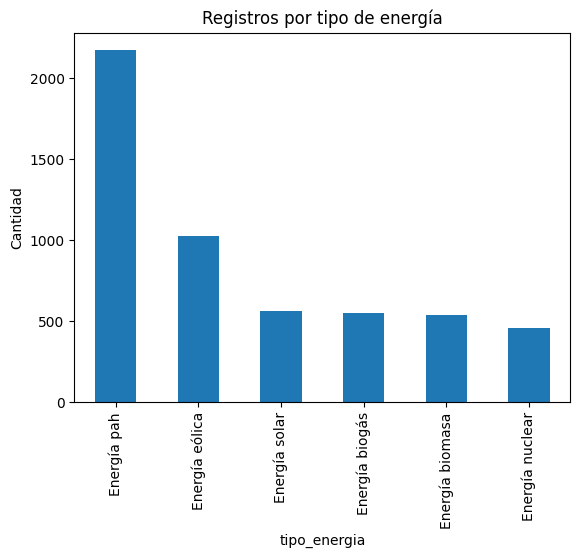

In [48]:
df['tipo_energia'].value_counts().plot(kind='bar')
plt.title('Registros por tipo de energía')
plt.ylabel('Cantidad')
plt.show()

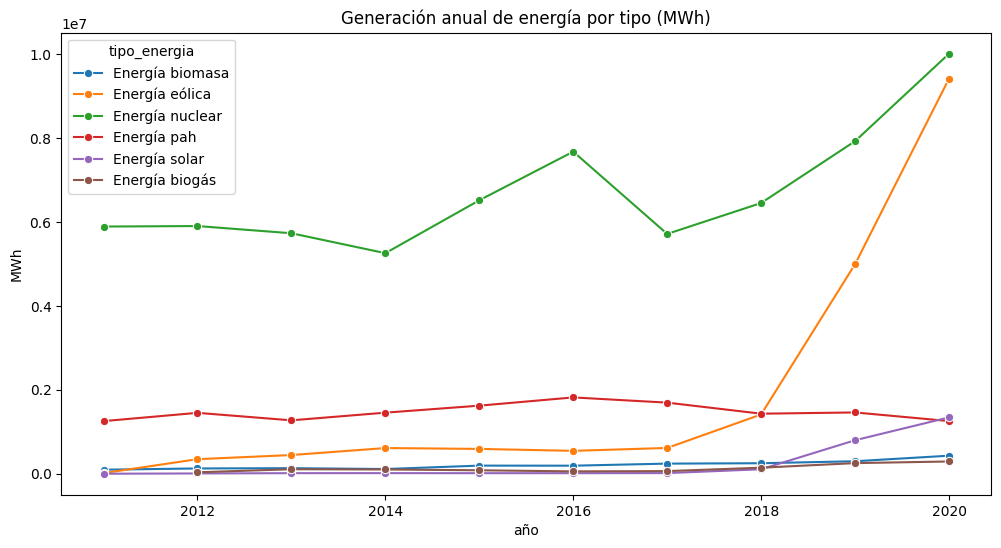

In [51]:
# 1. Convertimos la columna Fecha_Registro a formato datetime
df['Fecha_Registro'] = pd.to_datetime(df['Fecha_Registro'])

# 2. Creamos la columna 'año'
df['año'] = df['Fecha_Registro'].dt.year

# 3. Filtramos por el indicador 'Generación' y agrupamos para crear 'gen_anual'
gen_anual = df[df['indicador'] == 'Generación'].groupby(['año', 'tipo_energia'], as_index=False)['Medicion'].sum()

# Renombramos la columna agregada a 'valor'
gen_anual = gen_anual.rename(columns={'Medicion': 'valor'})

# Visualización — evolución temporal
plt.figure(figsize=(12,6))
sns.lineplot(data=gen_anual, x='año', y='valor', hue='tipo_energia', marker='o')
plt.title('Generación anual de energía por tipo (MWh)')
plt.ylabel('MWh')
plt.show()

**Pregunta de Negocio**

Variable objetivo: 'Generación'

¿Se puede predecir la generación mensual (MWh) de un tipo de energía renovable a partir de la potencia instalada, la provincia y/o la época del año?

Crear dos columnas, una con valores de generación y otra con valores de potencia instalada.